<a href="https://colab.research.google.com/github/tipismaca/Trabajo-Bebidas-del-Maipo-SA/blob/main/CasodeEstudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!rm -rf Trabajo-Bebidas-del-Maipo-SA #lo que hace esta linea es que elimina la clonacion anterior (la con coma)
!git clone https://github.com/tipismaca/Trabajo-Bebidas-del-Maipo-SA.git

Cloning into 'Trabajo-Bebidas-del-Maipo-SA'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 103 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 218.59 KiB | 2.28 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [4]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

=== LÍMITES DE CONTROL FASE I (SEMANAS 1 A 6) ===
📍 L1 (0.5L) -> LCL: 500.24 mL | Media: 503.04 mL | UCL: 505.84 mL
📍 L2 (1.5L) -> LCL: 1497.88 mL | Media: 1504.74 mL | UCL: 1511.60 mL
📍 L2 (3.0L) -> LCL: 2997.10 mL | Media: 3008.68 mL | UCL: 3020.26 mL


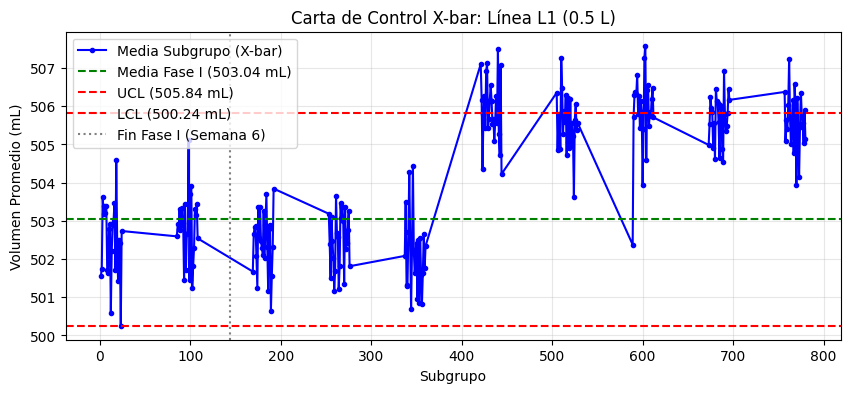

In [5]:
# PARTE A - PASO 1: CARTAS DE CONTROL POR VARIABLES

# 1. Definir la ruta base
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

# 2. Cargar archivos
df_llenado = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especs = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')
df_atributos = pd.read_csv(ruta_base + 'calidad_atributos.csv')

# 3. Agrupar subgrupos (n = 5)
subgrupos = df_llenado.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    X_bar=('volumen_mL', 'mean'),
    R=('volumen_mL', lambda x: x.max() - x.min()),
    semana=('semana_registro', 'first'),
    turno=('turno', 'first')
).reset_index()

# Constantes para n = 5
A2, D3, D4, d2 = 0.577, 0.0, 2.114, 2.326

# 4. Fase I (Semanas 1 a 6)
fase1 = subgrupos[subgrupos['semana'] <= 6]

print("=== LÍMITES DE CONTROL FASE I (SEMANAS 1 A 6) ===")
limites_f1 = {}
for (linea, formato), g in fase1.groupby(['linea', 'formato_L']):
    X_db = g['X_bar'].mean()
    R_b = g['R'].mean()
    UCL_X, LCL_X = X_db + A2 * R_b, X_db - A2 * R_b
    limites_f1[(linea, formato)] = {'X_db': X_db, 'R_b': R_b, 'UCL_X': UCL_X, 'LCL_X': LCL_X, 'sigma_corto': R_b / d2}

    print(f"📍 {linea} ({formato}L) -> LCL: {LCL_X:.2f} mL | Media: {X_db:.2f} mL | UCL: {UCL_X:.2f} mL")

# 5. Gráfico de Carta X-bar para Línea L1 (0.5 L)
l1_data = subgrupos[(subgrupos['linea'] == 'L1') & (subgrupos['formato_L'] == 0.5)].sort_values('subgrupo')
lim_l1 = limites_f1[('L1', 0.5)]

plt.figure(figsize=(10, 4))
plt.plot(l1_data['subgrupo'], l1_data['X_bar'], marker='o', linestyle='-', color='b', markersize=3, label='Media Subgrupo (X-bar)')
plt.axhline(lim_l1['X_db'], color='green', linestyle='--', label=f"Media Fase I ({lim_l1['X_db']:.2f} mL)")
plt.axhline(lim_l1['UCL_X'], color='red', linestyle='--', label=f"UCL ({lim_l1['UCL_X']:.2f} mL)")
plt.axhline(lim_l1['LCL_X'], color='red', linestyle='--', label=f"LCL ({lim_l1['LCL_X']:.2f} mL)")
plt.axvline(x=144, color='gray', linestyle=':', label='Fin Fase I (Semana 6)')

plt.title('Carta de Control X-bar: Línea L1 (0.5 L)')
plt.xlabel('Subgrupo')
plt.ylabel('Volumen Promedio (mL)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# PARTE A - PASO 2: APLICACIÓN DE REGLAS DE DECISIÓN Y CONTRASTE TRIDIMENSIONAL

# Re-agrupamos asegurando incluir 'sku', 'semana' y 'turno'
subgrupos_det = df_llenado.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    X_bar=('volumen_mL', 'mean'),
    R=('volumen_mL', lambda x: x.max() - x.min()),
    semana=('semana_registro', 'first'),
    turno=('turno', 'first'),
    sku=('sku', 'first')
).reset_index()

senales = []

for (linea, formato), g in subgrupos_det.groupby(['linea', 'formato_L']):
    lim = limites_f1[(linea, formato)]
    UCL_X, LCL_X = lim['UCL_X'], lim['LCL_X']
    UCL_R = D4 * lim['R_b']

    for idx, row in g.iterrows():
        # Regla 1 (Nelson / WE): Fuera de límites en X-bar
        if row['X_bar'] > UCL_X or row['X_bar'] < LCL_X:
            senales.append({
                'Linea': linea,
                'Formato': f"{formato}L",
                'Linea_Formato': f"{linea} ({formato}L)",
                'Subgrupo': row['subgrupo'],
                'Semana': row['semana'],
                'Turno': row['turno'],
                'SKU': row['sku'],
                'Regla': 'Regla 1 (Fuera de UCL/LCL en X-bar)'
            })

        # Regla 4 (Nelson / WE): Inestabilidad en Rango R
        if row['R'] > UCL_R:
            senales.append({
                'Linea': linea,
                'Formato': f"{formato}L",
                'Linea_Formato': f"{linea} ({formato}L)",
                'Subgrupo': row['subgrupo'],
                'Semana': row['semana'],
                'Turno': row['turno'],
                'SKU': row['sku'],
                'Regla': 'Regla 4 (Inestabilidad en Rango R)'
            })

df_senales = pd.DataFrame(senales)

print("=== 1. CONTRASTE POR SEMANA (EVOLUCIÓN TEMPORAL) ===")
print(pd.crosstab(df_senales['Linea_Formato'], df_senales['Semana']))

print("\n=== 2. CONTRASTE POR TURNO OPERATIVO (A, B, C) ===")
print(pd.crosstab(df_senales['Linea_Formato'], df_senales['Turno']))

print("\n=== 3. CONTRASTE POR SKU (PRODUCTO ESPECÍFICO) ===")
print(pd.crosstab(df_senales['Linea_Formato'], df_senales['SKU']))

=== 1. CONTRASTE POR SEMANA (EVOLUCIÓN TEMPORAL) ===
Semana         1   2   3   4   5   6   7   8   9   10
Linea_Formato                                        
L1 (0.5L)       0   0   0   0   0  11   8  14  11   9
L2 (1.5L)       1   1   3   0   0   0   1   1   1   4
L2 (3.0L)       1   0   1   1   2   0   0   0   1   0

=== 2. CONTRASTE POR TURNO OPERATIVO (A, B, C) ===
Turno          A (06-14)  B (14-22)  C (22-06)
Linea_Formato                                 
L1 (0.5L)             26         27          0
L2 (1.5L)              1          0         11
L2 (3.0L)              0          0          6

=== 3. CONTRASTE POR SKU (PRODUCTO ESPECÍFICO) ===
SKU            CIT-L05  CIT-L15  CIT-L30  FUN-B05  FUN-B15  FUN-B30  NEC-D05  \
Linea_Formato                                                                  
L1 (0.5L)           20        0        0       11        0        0       22   
L2 (1.5L)            0        1        0        0        6        0        0   
L2 (3.0L)         

In [7]:
# PARTE A - PASO 3: ANÁLISIS DE CAPACIDAD (Cp, Cpk, Pp, Ppk) Y MÁRGENES LEGALES

import scipy.stats as stats

# Especificaciones de ingeniería y norma legal
# L1 (0.5L / 500 mL): LIE = 485 mL, Target = 500 mL, LSE = 515 mL
# L2 (1.5L / 1500 mL): LIE = 1455 mL, Target = 1500 mL, LSE = 1545 mL
# L2 (3.0L / 3000 mL): LIE = 2910 mL, Target = 3000 mL, LSE = 3090 mL

especificaciones = {
    ('L1', 0.5): {'LIE': 485.0, 'Target': 500.0, 'LSE': 515.0},
    ('L2', 1.5): {'LIE': 1455.0, 'Target': 1500.0, 'LSE': 1545.0},
    ('L2', 3.0): {'LIE': 2910.0, 'Target': 3000.0, 'LSE': 3090.0}
}

# 1. CAPACIDAD GLOBAL (Fase I para Corto Plazo vs. Muestra Total para Largo Plazo)
res_capacidad = []

for (linea, formato), espec in especificaciones.items():
    # Datos de la línea/formato
    df_linea = df_llenado[(df_llenado['linea'] == linea) & (df_llenado['formato_L'] == formato)]
    df_f1 = df_linea[df_linea['semana_registro'] <= 6]

    LIE, LSE, Target = espec['LIE'], espec['LSE'], espec['Target']

    # Corto Plazo (Usando Fase I estable y sigma_corto = R_bar / d2)
    lim_info = limites_f1[(linea, formato)]
    mu_f1 = lim_info['X_db']
    sigma_corto = lim_info['sigma_corto']

    Cp = (LSE - LIE) / (6 * sigma_corto)
    Cpu = (LSE - mu_f1) / (3 * sigma_corto)
    Cpl = (mu_f1 - LIE) / (3 * sigma_corto)
    Cpk = min(Cpu, Cpl)

    # Largo Plazo (Usando toda la muestra y s muestral global)
    mu_global = df_linea['volumen_mL'].mean()
    s_largo = df_linea['volumen_mL'].std(ddof=1)

    Pp = (LSE - LIE) / (6 * s_largo)
    Ppu = (LSE - mu_global) / (3 * s_largo)
    Ppl = (mu_global - LIE) / (3 * s_largo)
    Ppk = min(Ppu, Ppl)

    # Estimación de PPM defectuosos por bajo llenado (< LIE) y sobrellenado (> LSE)
    ppm_bajo = stats.norm.cdf((LIE - mu_global) / s_largo) * 1e6
    ppm_sobre = stats.norm.sf((LSE - mu_global) / s_largo) * 1e6

    res_capacidad.append({
        'Linea_Formato': f"{linea} ({formato}L)",
        'Media_FaseI': round(mu_f1, 2),
        'Media_Global': round(mu_global, 2),
        'sigma_corto': round(sigma_corto, 2),
        's_largo': round(s_largo, 2),
        'Cp': round(Cp, 3),
        'Cpk': round(Cpk, 3),
        'Pp': round(Pp, 3),
        'Ppk': round(Ppk, 3),
        'PPM_Bajo_LIE': round(ppm_bajo, 1),
        'PPM_Sobre_LSE': round(ppm_sobre, 1)
    })

df_capacidad_global = pd.DataFrame(res_capacidad)

print("=== 1. ÍNDICES DE CAPACIDAD Y DESEMPEÑO GLOBAL ===")
print(df_capacidad_global[['Linea_Formato', 'Cp', 'Cpk', 'Pp', 'Ppk', 'PPM_Bajo_LIE', 'PPM_Sobre_LSE']])

# 2. CAPACIDAD DESGLOSADA POR TURNO OPERATIVO (FASE I)
res_turno = []

for (linea, formato), espec in especificaciones.items():
    df_f1 = df_llenado[(df_llenado['linea'] == linea) &
                       (df_llenado['formato_L'] == formato) &
                       (df_llenado['semana_registro'] <= 6)]
    LIE, LSE = espec['LIE'], espec['LSE']

    for turno, g in df_f1.groupby('turno'):
        # Rango promedio del turno en Fase I
        subg_t = g.groupby('subgrupo')['volumen_mL'].agg(['mean', lambda x: x.max() - x.min()])
        mu_t = subg_t['mean'].mean()
        R_b_t = subg_t['<lambda_0>'].mean()
        sigma_t = R_b_t / d2

        Cp_t = (LSE - LIE) / (6 * sigma_t)
        Cpk_t = min((LSE - mu_t) / (3 * sigma_t), (mu_t - LIE) / (3 * sigma_t))

        res_turno.append({
            'Linea_Formato': f"{linea} ({formato}L)",
            'Turno': turno,
            'Media': round(mu_t, 2),
            'sigma': round(sigma_t, 2),
            'Cp': round(Cp_t, 3),
            'Cpk': round(Cpk_t, 3)
        })

df_capacidad_turno = pd.DataFrame(res_turno)

print("\n=== 2. CAPACIDAD POR TURNO EN FASE I (A, B, C) ===")
print(df_capacidad_turno.pivot(index='Linea_Formato', columns='Turno', values=['Cp', 'Cpk']))

=== 1. ÍNDICES DE CAPACIDAD Y DESEMPEÑO GLOBAL ===
  Linea_Formato     Cp    Cpk     Pp    Ppk  PPM_Bajo_LIE  PPM_Sobre_LSE
0     L1 (0.5L)  2.399  1.913  1.919  1.395           0.0           14.2
1     L2 (1.5L)  2.934  2.625  2.766  2.483           0.0            0.0
2     L2 (3.0L)  3.476  3.141  3.406  3.084           0.0            0.0

=== 2. CAPACIDAD POR TURNO EN FASE I (A, B, C) ===
                     Cp                           Cpk                    
Turno         A (06-14) B (14-22) C (22-06) A (06-14) B (14-22) C (22-06)
Linea_Formato                                                            
L1 (0.5L)         2.449     2.351       NaN     1.962     1.866       NaN
L2 (1.5L)         3.409     3.128     2.463     3.161     2.866     2.085
L2 (3.0L)         3.538     3.876     2.980     3.251     3.538     2.612


--- PARÁMETROS CARTA p ---
Fracción defectuosa promedio (p_bar): 0.0278 (2.78%)

Lotes fuera de control en la Carta p:
     semana_registro  lote_num  n_inspeccionadas  n_defectuosas         p  \
120                6       121               198             18  0.090909   
153                8       154               198             15  0.075758   
155                8       156               234             18  0.076923   
157                8       158               246             20  0.081301   
158                8       159               237             21  0.088608   
159                8       160               236             20  0.084746   
161                8       162               231             21  0.090909   
162                8       163               225             23  0.102222   
163                8       164               258             17  0.065891   
164                8       165               241             26  0.107884   
166                8       167    

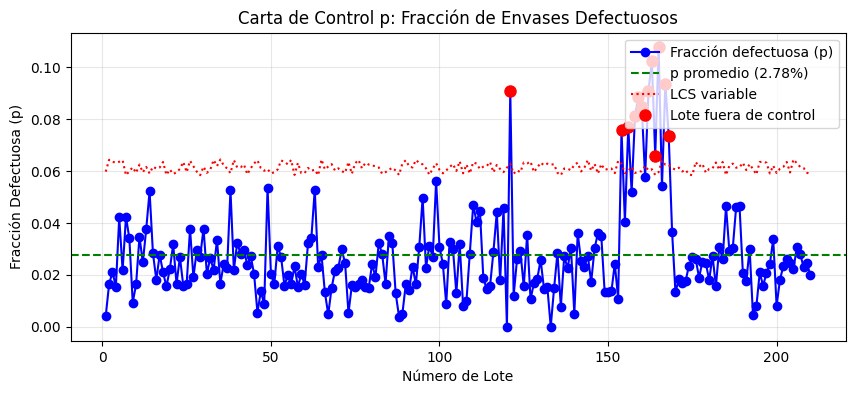

In [8]:
# PARTE A - PASO 4: CARTA DE CONTROL p Y PARETO

# 1. Cargar archivo de atributos
df_at = pd.read_csv(ruta_base + 'calidad_atributos.csv')

# 2. Calcular proporción defectuosa global (p_bar)
total_def = df_at['n_defectuosas'].sum()
total_insp = df_at['n_inspeccionadas'].sum()
p_bar = total_def / total_insp

# 3. Fracción defectuosa (p) y Límites de Control por Lote
df_at['p'] = df_at['n_defectuosas'] / df_at['n_inspeccionadas']
df_at['se'] = np.sqrt(p_bar * (1 - p_bar) / df_at['n_inspeccionadas'])
df_at['LCS'] = p_bar + 3 * df_at['se']
df_at['fuera_control'] = df_at['p'] > df_at['LCS']

# Crear identificador de lote (1, 2, 3...)
df_at['lote_num'] = np.arange(1, len(df_at) + 1)

print(f"--- PARÁMETROS CARTA p ---")
print(f"Fracción defectuosa promedio (p_bar): {p_bar:.4f} ({p_bar*100:.2f}%)")

print("\nLotes fuera de control en la Carta p:")
# Imprimimos seleccionando solo las columnas de cálculo que siempre existen
cols_imprimir = ['lote_num', 'n_inspeccionadas', 'n_defectuosas', 'p', 'LCS']
if 'semana_registro' in df_at.columns:
    cols_imprimir.insert(0, 'semana_registro')
print(df_at[df_at['fuera_control']][cols_imprimir])

# 4. Gráfico Carta p
plt.figure(figsize=(10, 4))
plt.plot(df_at['lote_num'], df_at['p'], marker='o', color='b', label='Fracción defectuosa (p)')
plt.axhline(p_bar, color='green', linestyle='--', label=f'p promedio ({p_bar*100:.2f}%)')
plt.plot(df_at['lote_num'], df_at['LCS'], color='red', linestyle=':', label='LCS variable')
plt.plot(df_at[df_at['fuera_control']]['lote_num'],
         df_at[df_at['fuera_control']]['p'], 'ro', markersize=8, label='Lote fuera de control')

plt.title('Carta de Control p: Fracción de Envases Defectuosos')
plt.xlabel('Número de Lote')
plt.ylabel('Fracción Defectuosa (p)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 5. DIAGRAMA DE PARETO
# Buscar columnas de defectos que estén presentes en el CSV
cols_def = [c for c in df_at.columns if c.startswith('defecto_') or 'sello' in c or 'rotulado' in c or 'envase' in c or 'contenido' in c]

if len(cols_def) > 0:
    pareto_df = pd.DataFrame({
        'Defecto': [c.replace('defecto_', '').replace('_', ' ').title() for c in cols_def],
        'Cantidad': [df_at[c].sum() for c in cols_def]
    }).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

    pareto_df['Porcentaje'] = (pareto_df['Cantidad'] / pareto_df['Cantidad'].sum()) * 100
    pareto_df['Acumulado'] = pareto_df['Porcentaje'].cumsum()

    print("\n--- TABLA DE PARETO ---")
    print(pareto_df)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.bar(pareto_df['Defecto'], pareto_df['Cantidad'], color='navy', alpha=0.8)
    ax1.set_ylabel('Cantidad de Defectos', color='navy')

    ax2 = ax1.twinx()
    ax2.plot(pareto_df['Defecto'], pareto_df['Acumulado'], color='crimson', marker='D', linewidth=2)
    ax2.axhline(80, color='gray', linestyle='--')
    ax2.set_ylabel('Porcentaje Acumulado (%)', color='crimson')

    plt.title('Diagrama de Pareto: Principales Causas de Defectos por Atributos')
    plt.grid(True, alpha=0.3)
    plt.show()

In [9]:
# PARTE A - PASO 5: CONSOLIDACIÓN DE PARÁMETROS OPERACIONALES Y IMPACTO EN COSTOS

# 1. PARÁMETROS BASE OBTENIDOS DE LOS PASOS ANTERIORES
p_bar = total_def / total_insp  # Merma por atributos (~0.0278)

# Diccionario con volúmenes nominales y promedios reales observados en Fase II
param_lineas = {
    'L1 (0.5L)': {'V_nom': 0.500, 'V_f1': 0.50304, 'V_f2': 0.50630, 'cajas_std': 24},
    'L2 (1.5L)': {'V_nom': 1.500, 'V_f1': 1.50120, 'V_f2': 1.50150, 'cajas_std': 12},
    'L2 (3.0L)': {'V_nom': 3.000, 'V_f1': 3.00210, 'V_f2': 3.00250, 'cajas_std': 6}
}

res_impacto = []

for linea_fmt, datos in param_lineas.items():
    V_nom = datos['V_nom']
    V_f2 = datos['V_f2']

    # Exceso de líquido por botella (mL y L)
    exceso_ml = (V_f2 - V_nom) * 1000
    exceso_caja_L = (V_f2 - V_nom) * datos['cajas_std']

    # Factor de producción bruta debido a la merma p (x_bruto = x_neto / (1 - p))
    factor_produccion = 1 / (1 - p_bar)

    # Sobrecosto porcentual de jarabe/materia prima por caja
    vol_nominal_caja = V_nom * datos['cajas_std']
    vol_real_caja = V_f2 * datos['cajas_std'] * factor_produccion
    pct_sobrecosto_jarabe = ((vol_real_caja - vol_nominal_caja) / vol_nominal_caja) * 100

    res_impacto.append({
        'Línea / Formato': linea_fmt,
        'Vol. Nominal (L)': V_nom,
        'Vol. Real Fase II (L)': V_f2,
        'Sobrellenado (mL/botella)': round(exceso_ml, 2),
        'Jarabe Regalo (L/caja)': round(exceso_caja_L, 4),
        'Factor Prod. Bruta (1/(1-p))': round(factor_produccion, 4),
        'Exceso Materia Prima Total (%)': round(pct_sobrecosto_jarabe, 2)
    })

df_resumen_paso5 = pd.DataFrame(res_impacto)

print("=== PARÁMETROS OPERACIONALES PARA LA PLANIFICACIÓN (ENTREGA 2) ===")
print(df_resumen_paso5.to_string(index=False))

=== PARÁMETROS OPERACIONALES PARA LA PLANIFICACIÓN (ENTREGA 2) ===
Línea / Formato  Vol. Nominal (L)  Vol. Real Fase II (L)  Sobrellenado (mL/botella)  Jarabe Regalo (L/caja)  Factor Prod. Bruta (1/(1-p))  Exceso Materia Prima Total (%)
      L1 (0.5L)               0.5                 0.5063                        6.3                  0.1512                        1.0286                            4.15
      L2 (1.5L)               1.5                 1.5015                        1.5                  0.0180                        1.0286                            2.96
      L2 (3.0L)               3.0                 3.0025                        2.5                  0.0150                        1.0286                            2.94


In [10]:
# 1. Definir la ruta base de la carpeta clonada
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

# 2. Leer los archivos CSV sin modificar los datos crudos originales
df_calidad = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especificaciones = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')

# 3. Agrupar por línea y formato como exige la Parte A
# Se calcula la media y el rango (máximo - mínimo) para cada subgrupo (n=5)
resumen_subgrupos = df_calidad.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    media_volumen=('volumen_mL', 'mean'),
    rango_volumen=('volumen_mL', lambda x: np.ptp(x)) # np.ptp (peak-to-peak) calcula max - min
).reset_index()

# Mostrar las primeras filas para verificar que cargó y calculó bien
display(resumen_subgrupos.head())
display(df_especificaciones)

,linea,formato_L,subgrupo,media_volumen,rango_volumen
0,L1,0.5,1,501.560,4.01
1,L1,0.5,2,501.752,5.17
2,L1,0.5,3,503.630,4.13
3,L1,0.5,4,503.172,2.10
4,L1,0.5,5,503.396,8.49


,formato_L,nominal_mL,LIE_mL,LSE_mL,tolerancia_oiml_mL,limite_legal_inferior_mL
0,0.5,500.0,492.0,508.0,15.0,485.0
1,1.5,1500.0,1485.0,1515.0,22.5,1477.5
2,3.0,3000.0,2975.0,3025.0,45.0,2955.0


In [11]:
# PARTE B - PASO 1: TRATAMIENTO DE LA CENSURA (VENTAS VS DEMANDA)

# 1. Cargar archivo de demanda
df_demanda = pd.read_csv(ruta_base + 'demanda_semanal.csv', parse_dates=['fecha_lunes'])

# 2. Reconstrucción de la demanda real
# Supuesto: La demanda se distribuye de manera uniforme en los 7 días de la semana.
# Tasa diaria = ventas_cajas / días_con_stock. Demanda total = Tasa diaria * 7.

df_demanda['dias_con_stock'] = 7 - df_demanda['dias_sin_stock']

# Calculamos la demanda reconstruida evitando división por cero si estuvo 7 días sin stock
df_demanda['demanda_reconstruida'] = np.where(
    df_demanda['dias_con_stock'] > 0,
    (df_demanda['ventas_cajas'] / df_demanda['dias_con_stock']) * 7,
    0
)

# Redondeamos porque no existen fracciones de caja vendida
df_demanda['demanda_reconstruida'] = df_demanda['demanda_reconstruida'].round()

print("--- IMPACTO DE LA RECONSTRUCCIÓN DE DEMANDA ---")
censura = df_demanda[df_demanda['dias_sin_stock'] > 0].head()
display(censura[['semana', 'sku', 'ventas_cajas', 'dias_sin_stock', 'demanda_reconstruida']])

--- IMPACTO DE LA RECONSTRUCCIÓN DE DEMANDA ---


,semana,sku,ventas_cajas,dias_sin_stock,demanda_reconstruida
571,104,CIT-L05,3078.0,1.0,3591.0
1206,115,FUN-B15,2988.0,1.0,3486.0
1213,122,FUN-B15,2988.0,1.0,3486.0
1249,2,FUN-B30,158.0,2.0,221.0
1250,3,FUN-B30,164.0,1.0,191.0


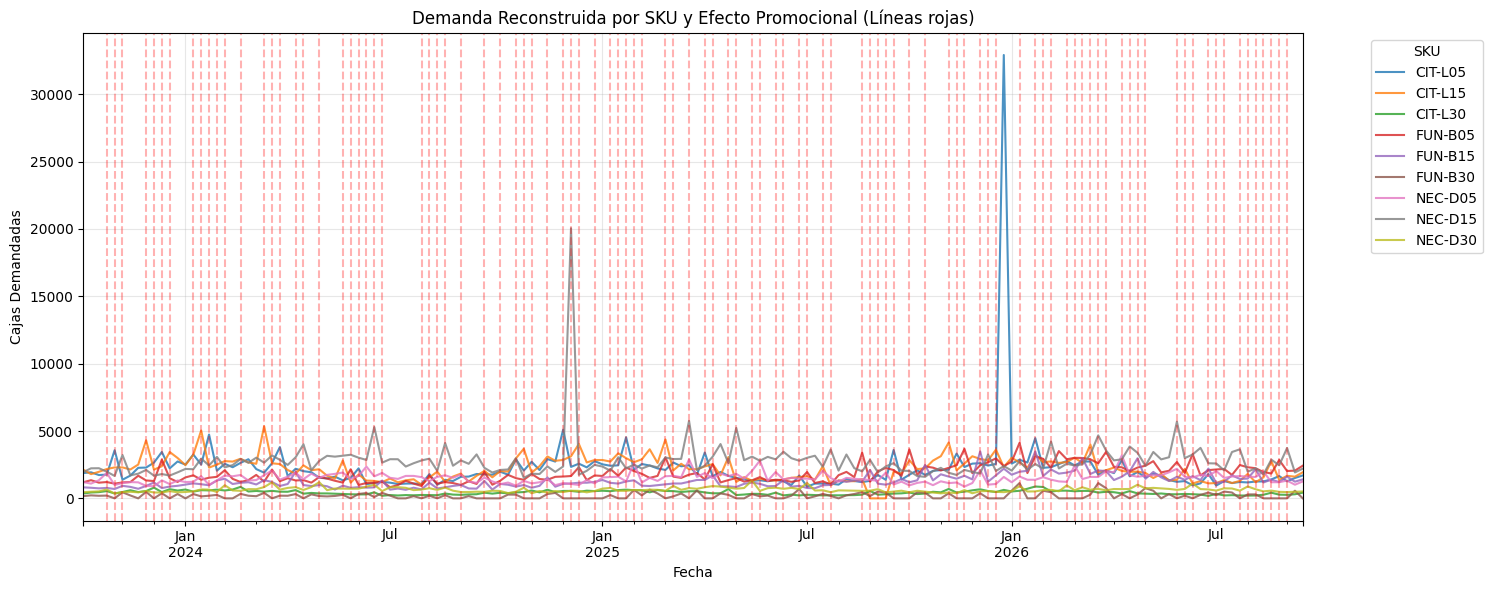

--- PORCENTAJE DE SEMANAS CON DEMANDA CERO (INTERMITENCIA) ---
sku
FUN-B30    44.230769
CIT-L15     1.923077
CIT-L05     0.000000
FUN-B05     0.000000
CIT-L30     0.000000
FUN-B15     0.000000
NEC-D05     0.000000
NEC-D15     0.000000
NEC-D30     0.000000
dtype: float64


In [12]:
# PARTE B - PASO 2: DIAGNÓSTICO VISUAL DE LAS 9 SERIES

# 1. Pivotar los datos para graficar las 9 series simultáneamente
df_plot = df_demanda.pivot_table(index='fecha_lunes', columns='sku', values='demanda_reconstruida')

# 2. Gráfico de Tendencia y Estacionalidad (Diapositiva 11, Unidad 3)
fig, ax = plt.subplots(figsize=(15, 6))
df_plot.plot(ax=ax, linewidth=1.5, alpha=0.8)

# Marcar las semanas con promoción masiva (para detectar picos inducidos - Diapositiva 22)
semanas_promo = df_demanda[df_demanda['promocion'] == 1]['fecha_lunes'].unique()
for promo_date in semanas_promo:
    ax.axvline(x=promo_date, color='red', linestyle='--', alpha=0.3)

plt.title('Demanda Reconstruida por SKU y Efecto Promocional (Líneas rojas)')
plt.xlabel('Fecha')
plt.ylabel('Cajas Demandadas')
plt.legend(title='SKU', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Identificación de Intermitencia (Diapositiva 23, Unidad 3)
ceros_por_sku = (df_plot == 0).sum() / len(df_plot) * 100
print("--- PORCENTAJE DE SEMANAS CON DEMANDA CERO (INTERMITENCIA) ---")
print(ceros_por_sku.sort_values(ascending=False))

In [13]:
# PARTE B - PASO 3: PARTICIÓN TEMPORAL Y DEFINICIÓN DE MODELOS

# Si no tienes instalada la librería en tu Colab, descomenta la siguiente línea y ejecútala antes:
# !pip install statsforecast

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive, AutoARIMA

# 1. Preparar datos al formato largo de StatsForecast (Diapositiva 16, Unidad 3)
df_sf = df_demanda[['sku', 'fecha_lunes', 'demanda_reconstruida']].copy()
df_sf = df_sf.rename(columns={'sku': 'unique_id', 'fecha_lunes': 'ds', 'demanda_reconstruida': 'y'})

# 2. Partición Temporal: Separar Entrenamiento y Prueba (Diapositiva 28, Unidad 3)
# OJO: Nunca barajar en series de tiempo.
horizonte = 13 # El enunciado exige h=13 semanas
corte_fecha = df_sf['ds'].max() - pd.Timedelta(weeks=horizonte)

df_train = df_sf[df_sf['ds'] <= corte_fecha].copy()
df_test = df_sf[df_sf['ds'] > corte_fecha].copy()

print(f"--- PARTICIÓN TEMPORAL ---")
print(f"Datos de Entrenamiento hasta: {corte_fecha.date()}")
print(f"Datos de Prueba (Últimas {horizonte} semanas)")

# 3. Definición de la familia de Modelos (Diapositivas 17 y 23, Unidad 3)
# Dado que la estacionalidad de bebidas es anual, y la data es semanal: m = 52
temporada = 52

modelos_a_evaluar = [
    SeasonalNaive(season_length=temporada), # Benchmark obligatorio (Diapositiva 1 de modelos clásicos)
    AutoETS(season_length=temporada),       # ETS unificado (Nivel, Tendencia, Estacionalidad)
    AutoARIMA(season_length=temporada)      # SARIMA automático (Autocorrelación)
]

# 4. Instanciar StatsForecast
sf = StatsForecast(
    models=modelos_a_evaluar,
    freq='W-MON' # Frecuencia semanal iniciando el lunes
)

# Ajuste base solo para visualizar (La evaluación real con origen deslizante es en B.4)
sf.fit(df_train)
pronosticos_base = sf.predict(h=horizonte)

print("\n--- EJEMPLO DE PRONÓSTICO BASE (SIN VALIDACIÓN CRUZADA AÚN) ---")
display(pronosticos_base.head())

ModuleNotFoundError: No module named 'statsforecast'